# 3 · Análisis del efecto de la elección de métrica

Material para el apartado **6.1 Comparabilidad contra literatura** de la memoria.

Una parte de la diferencia entre los resultados de este trabajo y los publicados sobre el mismo
corpus no procede de la calidad de los modelos, sino de **qué métrica se reporta**. Este
notebook lo cuantifica sobre los propios modelos del trabajo.

No entrena nada nuevo: reconstruye el Random Forest de la línea principal con los
hiperparámetros ya seleccionados en `3.1.ModelizaciónRF_vf`, reproduce sus predicciones sobre
test y calcula, **a partir de ellas**, todas las variantes de métrica.

Se comprueba además que las cifras reproducidas coinciden con las publicadas en el capítulo 5,
como control de que el pipeline es el mismo.

## 0. Setup y datos

In [7]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (f1_score, precision_recall_fscore_support, accuracy_score,
                             roc_auc_score, confusion_matrix, mean_squared_error, r2_score)
import warnings; warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
PALETA4 = ['#8ecae6', '#219ebc', '#fb8500', '#e63946']

path_df_features = r'C:/Users/tblxa/Desktop/Master/UNIR_IA_TFE/output/df_acoustic_features_vf.csv'
path_output      = r'C:/Users/tblxa/Desktop/Master/UNIR_IA_TFE/output'

# ---- constantes identicas a 3.1.ModelizacionRF_vf ----
PHQ_THRESHOLD = 10
RANDOM_STATE  = 42
N_CV_FOLDS    = 5
K_FEATURES    = 20

COLS_EXCLUDE = ['participant_id', 'phq8_binary', 'path_audio',
                'path_transcript', 'split', 'durAudio', 'durSession']
TARGET = 'phq8_score'
ACOUSTIC_PREFIXES = ('f0_', 'energy_', 'mfcc', 'centroid_', 'bandwidth_',
                     'rolloff_', 'zcr_', 'hnr_', 'jitter_', 'shimmer_')

# hiperparametros ya seleccionados por RandomizedSearchCV en 3.1
RF_PARAMS = dict(n_estimators=546, max_depth=10, min_samples_split=24,
                 min_samples_leaf=2, max_features='log2')

df = pd.read_csv(path_df_features)
COLS_FEATURES = [c for c in df.columns if c not in COLS_EXCLUDE + [TARGET]]
ACOUSTIC_COLS = [c for c in COLS_FEATURES if c.startswith(ACOUSTIC_PREFIXES)]

td = df[df.split.isin(['train', 'dev'])]
te = df[df.split == 'test']
X_td, y_td = td[COLS_FEATURES], td[TARGET]
X_te, y_te = te[COLS_FEATURES], te[TARGET]
ybin_td = (y_td >= PHQ_THRESHOLD).astype(int).values
ybin_te = (y_te >= PHQ_THRESHOLD).astype(int).values

print(f'train+dev {len(X_td)} sesiones ({ybin_td.sum()} con sintomatologia)')
print(f'test      {len(X_te)} sesiones ({ybin_te.sum()} con sintomatologia)')
print(f'prevalencia en test: {ybin_te.mean():.3f}')

train+dev 140 sesiones (43 con sintomatologia)
test      46 sesiones (14 con sintomatologia)
prevalencia en test: 0.304


## 1. Reconstrucción del modelo y control de reproducibilidad

Se reconstruye el pipeline de la línea principal y se comprueba que las cifras coinciden con las publicadas.

In [8]:
class GenderZScoreScaler(BaseEstimator, TransformerMixin):
    """Z-score de las columnas indicadas dentro de cada grupo de sexo."""
    def __init__(self, cols, gender_col='gender'):
        self.cols, self.gender_col = cols, gender_col
    def fit(self, X, y=None):
        self.stats_ = {}
        for g, sub in X.groupby(self.gender_col):
            self.stats_[g] = (sub[self.cols].mean(),
                              sub[self.cols].std(ddof=0).replace(0, 1.0))
        self.global_ = (X[self.cols].mean(), X[self.cols].std(ddof=0).replace(0, 1.0))
        return self
    def transform(self, X):
        X = X.copy()
        for g, idx in X.groupby(self.gender_col).groups.items():
            mu, sd = self.stats_.get(g, self.global_)
            X.loc[idx, self.cols] = (X.loc[idx, self.cols] - mu) / sd
        return X


class DropColumns(BaseEstimator, TransformerMixin):
    def __init__(self, cols): self.cols = cols
    def fit(self, X, y=None): return self
    def transform(self, X): return X.drop(columns=[c for c in self.cols if c in X.columns])


def build_model():
    return Pipeline([('gender',     GenderZScoreScaler(ACOUSTIC_COLS)),
                     ('dropgender', DropColumns(['gender'])),
                     ('scaler',     StandardScaler()),
                     ('select',     SelectKBest(f_regression, k=K_FEATURES)),
                     ('rf',         RandomForestRegressor(random_state=RANDOM_STATE,
                                                          n_jobs=-1, **RF_PARAMS))])


cv = StratifiedKFold(N_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_splits = list(cv.split(X_td, ybin_td))

# predicciones out-of-fold -> umbral optimo (mismo procedimiento que en 3.1)
oof = np.zeros(len(X_td))
for i_tr, i_va in cv_splits:
    m = build_model().fit(X_td.iloc[i_tr], y_td.iloc[i_tr])
    oof[i_va] = m.predict(X_td.iloc[i_va])

ths = np.linspace(oof.min(), oof.max(), 200)
THR_OPT = ths[int(np.argmax([f1_score(ybin_td, (oof >= t).astype(int), zero_division=0)
                             for t in ths]))]

# modelo final y predicciones sobre test
modelo = build_model().fit(X_td, y_td)
pred_te = modelo.predict(X_te)

print(f'Umbral optimo sobre OOF: {THR_OPT:.2f}')
print(f'\nControl frente a las cifras publicadas en el capitulo 5:')
print(f'  RMSE test  {np.sqrt(mean_squared_error(y_te, pred_te)):.3f}   (publicado 6,120)')
print(f'  R2 test    {r2_score(y_te, pred_te):.3f}   (publicado 0,089)')
print(f'  AUC test   {roc_auc_score(ybin_te, pred_te):.3f}   (publicado 0,737)')

Umbral optimo sobre OOF: 4.55

Control frente a las cifras publicadas en el capitulo 5:
  RMSE test  6.120   (publicado 6,120)
  R2 test    0.089   (publicado 0,089)
  AUC test   0.737   (publicado 0,737)


## 2. El mismo conjunto de predicciones, seis métricas

In [9]:
def metricas(y_real, y_pred_bin):
    """Todas las variantes de metrica sobre un mismo conjunto de predicciones binarias."""
    pr, rc, f1, _ = precision_recall_fscore_support(y_real, y_pred_bin, average='binary',
                                                    pos_label=1, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_real, y_pred_bin, labels=[0, 1]).ravel()
    return {
        'Precisión (clase positiva)': pr,
        'Sensibilidad (clase positiva)': rc,
        'F1 de la clase positiva': f1,
        'F1 macro': f1_score(y_real, y_pred_bin, average='macro', zero_division=0),
        'F1 ponderado': f1_score(y_real, y_pred_bin, average='weighted', zero_division=0),
        'Accuracy': accuracy_score(y_real, y_pred_bin),
        'VP': tp, 'FP': fp, 'FN': fn, 'VN': tn,
    }


escenarios = {
    f'RF · umbral nominal (≥ {PHQ_THRESHOLD})': (pred_te >= PHQ_THRESHOLD).astype(int),
    f'RF · umbral optimizado (≥ {THR_OPT:.2f})': (pred_te >= THR_OPT).astype(int),
    'Trivial · todos deprimidos': np.ones(len(ybin_te), int),
    'Trivial · todos no deprimidos': np.zeros(len(ybin_te), int),
}

tabla = pd.DataFrame({k: metricas(ybin_te, v) for k, v in escenarios.items()})
print(tabla.round(3).to_string())

                               RF · umbral nominal (≥ 10)  RF · umbral optimizado (≥ 4.55)  Trivial · todos deprimidos  Trivial · todos no deprimidos
Precisión (clase positiva)                          0.600                            0.341                       0.304                          0.000
Sensibilidad (clase positiva)                       0.214                            1.000                       1.000                          0.000
F1 de la clase positiva                             0.316                            0.509                       0.467                          0.000
F1 macro                                            0.569                            0.390                       0.233                          0.410
F1 ponderado                                        0.668                            0.343                       0.142                          0.571
Accuracy                                            0.717                            0.413          

### 2.1 Lectura

In [10]:
print('LECTURA DEL RESULTADO\n' + '=' * 72)
rf_nom = tabla[f'RF · umbral nominal (≥ {PHQ_THRESHOLD})']
triv   = tabla['Trivial · todos no deprimidos']

print(f"""
1) Un mismo conjunto de predicciones admite lecturas muy distintas.
   El Random Forest con umbral nominal obtiene:
       F1 de la clase positiva : {rf_nom['F1 de la clase positiva']:.3f}
       F1 ponderado            : {rf_nom['F1 ponderado']:.3f}
       Accuracy                : {rf_nom['Accuracy']:.3f}
   Reportar la segunda o la tercera en lugar de la primera multiplica el valor
   comunicado por {rf_nom['Accuracy'] / rf_nom['F1 de la clase positiva']:.1f}, sin cambiar una sola prediccion.

2) La causa es la prevalencia: la clase mayoritaria supone el {100*(1-ybin_te.mean()):.1f} % de la muestra,
   y tanto el F1 ponderado como la accuracy estan dominados por ella.

3) Prueba definitiva: el clasificador que no detecta NINGUN caso obtiene
       F1 ponderado : {triv['F1 ponderado']:.3f}
       Accuracy     : {triv['Accuracy']:.3f}
   cifras superiores a las de varios resultados publicados sobre este corpus,
   con VP = {int(triv['VP'])}.
""")

LECTURA DEL RESULTADO

1) Un mismo conjunto de predicciones admite lecturas muy distintas.
   El Random Forest con umbral nominal obtiene:
       F1 de la clase positiva : 0.316
       F1 ponderado            : 0.668
       Accuracy                : 0.717
   Reportar la segunda o la tercera en lugar de la primera multiplica el valor
   comunicado por 2.3, sin cambiar una sola prediccion.

2) La causa es la prevalencia: la clase mayoritaria supone el 69.6 % de la muestra,
   y tanto el F1 ponderado como la accuracy estan dominados por ella.

3) Prueba definitiva: el clasificador que no detecta NINGUN caso obtiene
       F1 ponderado : 0.571
       Accuracy     : 0.696
   cifras superiores a las de varios resultados publicados sobre este corpus,
   con VP = 0.



## 3. Barrido del umbral

No solo cambia el valor comunicado: cada métrica se maximiza en un umbral distinto.

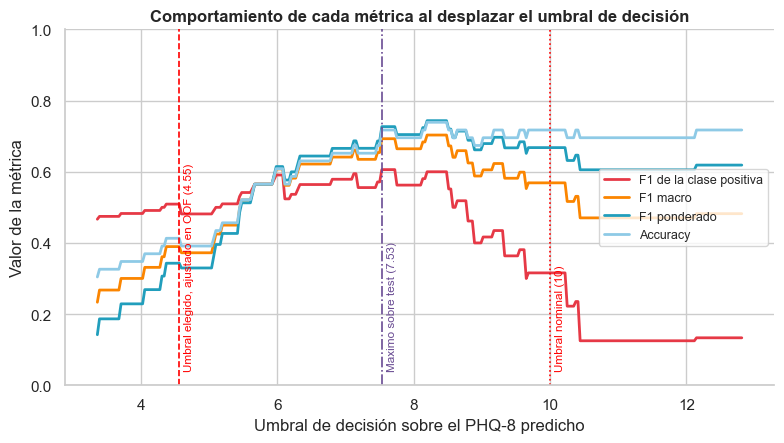

Brecha maxima entre accuracy y F1 de la clase positiva: 0.584 (umbral 12.15)
Brecha en el umbral nominal (10): 0.402

Umbral que maximiza cada metrica sobre test:
   F1 de la clase positiva        7.53
   F1 macro                       8.20
   F1 ponderado                   8.20
   Accuracy                       8.20

POR QUE EL UMBRAL ELEGIDO NO COINCIDE CON EL MAXIMO DE LA CURVA
El umbral se ajusta sobre las predicciones out-of-fold de train+dev, NUNCA sobre
test. Por eso el maximo de la curva de test cae en otro punto, y asi debe ser:
elegirlo sobre test seria seleccionar sobre el conjunto de evaluacion.

  Umbral elegido (OOF)       4.55  ->  F1 en OOF 0.506  |  F1 en test 0.509
  Maximo sobre test          7.53  ->  F1 en test 0.606
  Optimismo capturable      +0.097 de F1

El 37 % del rango de umbrales bate en test al elegido, entre 5.19 y
8.77. Que el F1 en OOF (0.506) y en test (0.509) sean casi identicos
indica que el umbral generaliza bien, que es lo que se le pide.

Lectura:

In [ ]:
# Como se comporta cada metrica al mover el umbral
rejilla = np.linspace(pred_te.min(), pred_te.max(), 300)
curvas = {'F1 de la clase positiva': [], 'F1 macro': [], 'F1 ponderado': [], 'Accuracy': []}
for t in rejilla:
    m = metricas(ybin_te, (pred_te >= t).astype(int))
    for k in curvas:
        curvas[k].append(m[k])

fig, ax = plt.subplots(figsize=(8, 4.6))
for (k, v), c in zip(curvas.items(), PALETA4[::-1]):
    ax.plot(rejilla, v, label=k, color=c, linewidth=2)

# El umbral que maximiza el F1 sobre el propio test NO es admisible como criterio:
# se representa unicamente para cuantificar el optimismo que capturaria elegirlo ahi.
f1_pos = np.array(curvas['F1 de la clase positiva'])
THR_TEST = rejilla[int(np.argmax(f1_pos))]

for t, etq, est, col in [
        (THR_OPT, f'Umbral elegido, ajustado en OOF ({THR_OPT:.2f})', '--', 'red'),
        (PHQ_THRESHOLD, f'Umbral nominal ({PHQ_THRESHOLD})', ':', 'red'),
        (THR_TEST, f'Maximo sobre test ({THR_TEST:.2f})', '-.', '#6A4C93')]:
    ax.axvline(t, color=col, linestyle=est, linewidth=1.2)
    ax.text(t + .08, .04, etq, rotation=90, va='bottom', fontsize=8.5, color=col)

ax.set_xlabel('Umbral de decisión sobre el PHQ-8 predicho')
ax.set_ylabel('Valor de la métrica')
ax.set_ylim(0, 1.0)
ax.set_title('Comportamiento de cada métrica al desplazar el umbral de decisión',
             fontweight='bold')
ax.legend(fontsize=9, loc='center right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(path_output + '/cap6_barrido_umbral.png', dpi=200, bbox_inches='tight',
            facecolor='white')
plt.show()

brecha = np.array(curvas['Accuracy']) - np.array(curvas['F1 de la clase positiva'])
i_max = int(np.argmax(brecha))
print(f'Brecha maxima entre accuracy y F1 de la clase positiva: {brecha[i_max]:.3f} '
      f'(umbral {rejilla[i_max]:.2f})')
print(f'Brecha en el umbral nominal ({PHQ_THRESHOLD}): '
      f'{np.interp(PHQ_THRESHOLD, rejilla, brecha):.3f}')

opt = {k: rejilla[int(np.argmax(v))] for k, v in curvas.items()}
print('\nUmbral que maximiza cada metrica sobre test:')
for k, v in opt.items():
    print(f'   {k:28s} {v:6.2f}')

f1_elegido = f1_score(ybin_te, (pred_te >= THR_OPT).astype(int), zero_division=0)
f1_maximo  = f1_pos.max()
mejores    = f1_pos > f1_elegido
print(f'''
POR QUE EL UMBRAL ELEGIDO NO COINCIDE CON EL MAXIMO DE LA CURVA
{'=' * 72}
El umbral se ajusta sobre las predicciones out-of-fold de train+dev, NUNCA sobre
test. Por eso el maximo de la curva de test cae en otro punto, y asi debe ser:
elegirlo sobre test seria seleccionar sobre el conjunto de evaluacion.

  Umbral elegido (OOF)      {THR_OPT:5.2f}  ->  F1 en OOF {f1_score(ybin_td, (oof >= THR_OPT).astype(int)):.3f}  |  F1 en test {f1_elegido:.3f}
  Maximo sobre test         {THR_TEST:5.2f}  ->  F1 en test {f1_maximo:.3f}
  Optimismo capturable      {f1_maximo - f1_elegido:+.3f} de F1

El {100 * mejores.mean():.0f} % del rango de umbrales bate en test al elegido, entre {rejilla[mejores].min():.2f} y
{rejilla[mejores].max():.2f}. Que el F1 en OOF ({f1_score(ybin_td, (oof >= THR_OPT).astype(int)):.3f}) y en test ({f1_elegido:.3f}) sean casi identicos
indica que el umbral generaliza bien, que es lo que se le pide.''')

## 4. Figura para la memoria

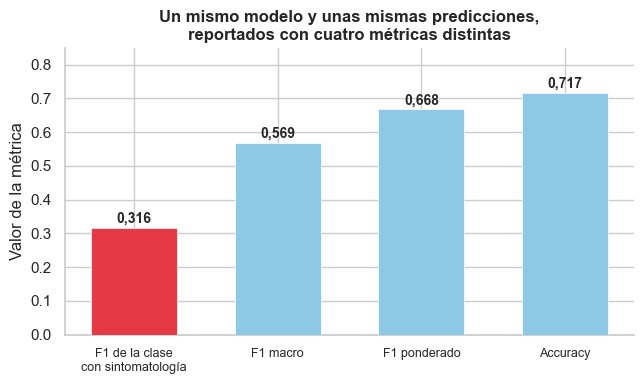

Guardado: output/cap6_efecto_metrica.png · output/cap6_barrido_umbral.png · output/tabla_efecto_metrica.csv


In [12]:
# Figura para la memoria: el mismo modelo con cuatro metricas
METRICAS = ['F1 de la clase positiva', 'F1 macro', 'F1 ponderado', 'Accuracy']
vals = [rf_nom[m] for m in METRICAS]
etq  = ['F1 de la clase\ncon sintomatología', 'F1 macro', 'F1 ponderado', 'Accuracy']

fig, ax = plt.subplots(figsize=(6.6, 4.0))
x = np.arange(len(METRICAS))
bars = ax.bar(x, vals, color=[PALETA4[3]] + [PALETA4[0]] * 3,
              width=.6, edgecolor='white', linewidth=.5, zorder=3)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + .015, f'{v:.3f}'.replace('.', ','),
            ha='center', fontsize=10, fontweight='bold', zorder=5)
ax.set_xticks(x); ax.set_xticklabels(etq, fontsize=9)
ax.set_ylabel('Valor de la métrica'); ax.set_ylim(0, 0.85)
ax.set_title('Un mismo modelo y unas mismas predicciones,\nreportados con cuatro métricas distintas',
             fontweight='bold', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(path_output + '/cap6_efecto_metrica.png', dpi=200, bbox_inches='tight',
            facecolor='white')
plt.show()

tabla.round(4).to_csv(path_output + '/tabla_efecto_metrica.csv')
print('Guardado: output/cap6_efecto_metrica.png · output/cap6_barrido_umbral.png · '
      'output/tabla_efecto_metrica.csv')